# Exploratory Data Analysis — Lyrics Genre Dataset

This notebook explores the prepared dataset: genre distributions, lyrics length
statistics, and word clouds per genre.

In [1]:
import sys, os
os.chdir(os.path.join(os.path.dirname(os.getcwd()), '') if 'notebooks' in os.getcwd() else os.getcwd())
# Ensure we run from the project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print('Working dir:', os.getcwd())

Working dir: /Users/junhohong/Desktop/stat359/student/final_project


In [2]:
from datasets import load_from_disk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

sns.set_theme(style='whitegrid', font_scale=1.2)
GENRE_ORDER = ['rap', 'pop', 'rock', 'country', 'rb']
GENRE_LABELS = {'rap': 'Rap/Hip-Hop', 'pop': 'Pop', 'rock': 'Rock', 'country': 'Country', 'rb': 'R&B'}
PALETTE = sns.color_palette('Set2', n_colors=5)

In [3]:
ds = load_from_disk('data/processed')
print(ds)
for split in ds:
    print(f'{split}: {len(ds[split])} rows')

DatasetDict({
    train: Dataset({
        features: ['title', 'artist', 'lyrics', 'label', 'genre'],
        num_rows: 3999
    })
    validation: Dataset({
        features: ['title', 'artist', 'lyrics', 'label', 'genre'],
        num_rows: 500
    })
    test: Dataset({
        features: ['title', 'artist', 'lyrics', 'label', 'genre'],
        num_rows: 500
    })
})
train: 3999 rows
validation: 500 rows
test: 500 rows


In [4]:
# Combine all splits for overall EDA
from datasets import concatenate_datasets
all_data = concatenate_datasets([ds['train'], ds['validation'], ds['test']])
df = all_data.to_pandas()
df['word_count'] = df['lyrics'].str.split().str.len()
df['char_count'] = df['lyrics'].str.len()
df.head()

,title,artist,lyrics,label,genre,word_count,char_count
0,Universal,Orchestral Manoeuvres in the Dark,It doesn’t matter if you’re black or white\nOr...,1,pop,140,737
1,They Try,Rascal Flatts,Nobody thought that we'd last as long as we ha...,3,country,137,690
2,Sweet Temptation,Merle Travis,"Sweet temptation, that's what you are to me\nT...",3,country,137,729
3,The Saddest Story Ever Told,Benjamin Gibbard,We used to go out in the summer nights and dan...,1,pop,155,742
4,What Am I Supposed To Do,Sal Houdini,(Verse 1)\nYou didn’t hear from me in the morn...,4,rb,417,2000


## 1. Genre Distribution

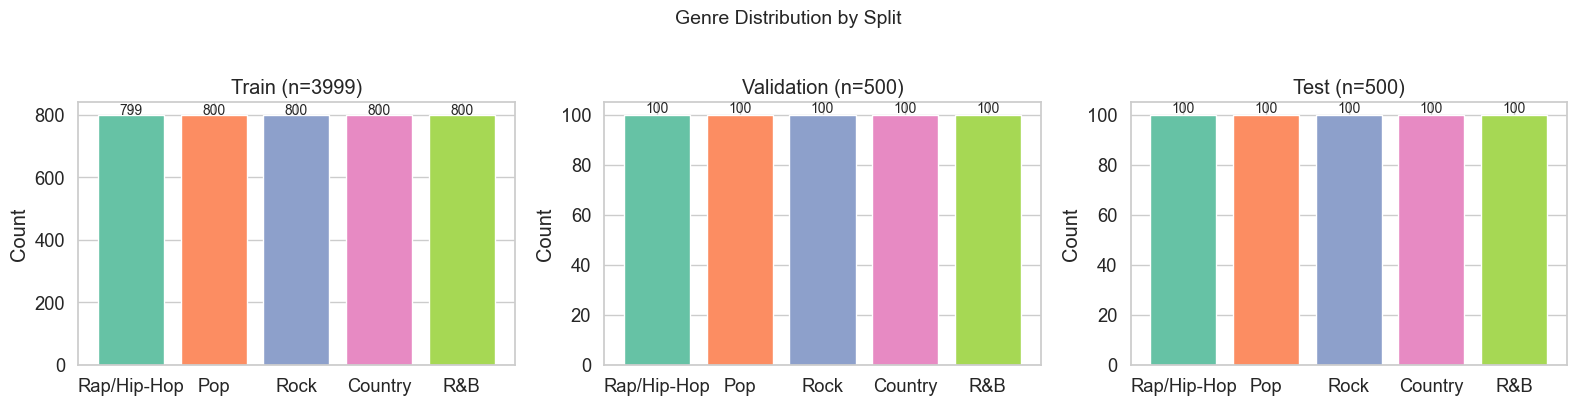

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, split_name in zip(axes, ['train', 'validation', 'test']):
    split_df = ds[split_name].to_pandas()
    counts = split_df['genre'].value_counts().reindex(GENRE_ORDER)
    ax.bar([GENRE_LABELS[g] for g in GENRE_ORDER], counts.values, color=PALETTE)
    ax.set_title(f'{split_name.capitalize()} (n={len(split_df)})')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 1, str(v), ha='center', fontsize=10)
plt.suptitle('Genre Distribution by Split', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('results/figures/genre_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Lyrics Length Statistics

In [6]:
print(df.groupby('genre')[['word_count', 'char_count']].describe().round(1))

        word_count                                                 char_count  \
             count   mean    std   min    25%    50%    75%    max      count   
genre                                                                           
country     1000.0  219.2   84.6  30.0  156.0  208.5  283.0  442.0     1000.0   
pop         1000.0  217.0   95.0  22.0  145.0  204.0  279.2  437.0     1000.0   
rap          999.0  333.0   94.5  25.0  283.5  375.0  400.0  450.0      999.0   
rb          1000.0  277.4  106.3  25.0  192.0  285.0  378.2  468.0     1000.0   
rock        1000.0  196.0   89.7  20.0  130.0  184.0  253.0  456.0     1000.0   

                                                               
           mean    std    min     25%     50%     75%     max  
genre                                                          
country  1092.0  420.4  153.0   768.5  1039.0  1392.8  2000.0  
pop      1085.8  468.9  112.0   722.0  1017.5  1401.0  2000.0  
rap      1671.6  470.5  140.0  

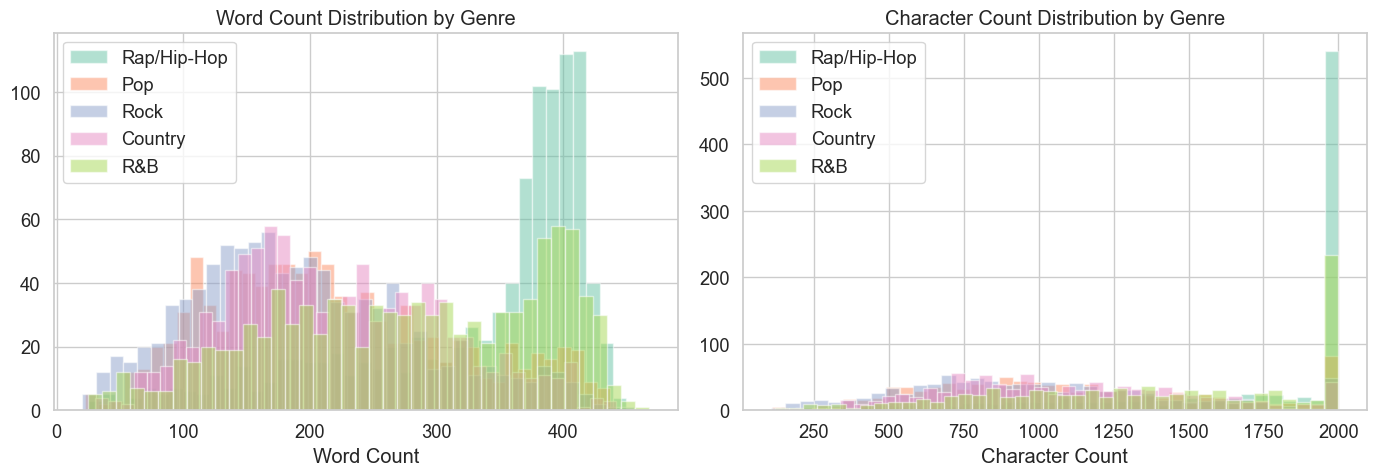

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for genre, color in zip(GENRE_ORDER, PALETTE):
    subset = df[df['genre'] == genre]
    axes[0].hist(subset['word_count'], bins=40, alpha=0.5, label=GENRE_LABELS[genre], color=color)
    axes[1].hist(subset['char_count'], bins=40, alpha=0.5, label=GENRE_LABELS[genre], color=color)

axes[0].set_xlabel('Word Count')
axes[0].set_title('Word Count Distribution by Genre')
axes[0].legend()
axes[1].set_xlabel('Character Count')
axes[1].set_title('Character Count Distribution by Genre')
axes[1].legend()
plt.tight_layout()
plt.savefig('results/figures/lyrics_length_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/1t/64tr2w5177bdzft8dqnkzzwr0000gn/T/ipykernel_24900/1181252316.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='genre', y='word_count', palette=PALETTE,


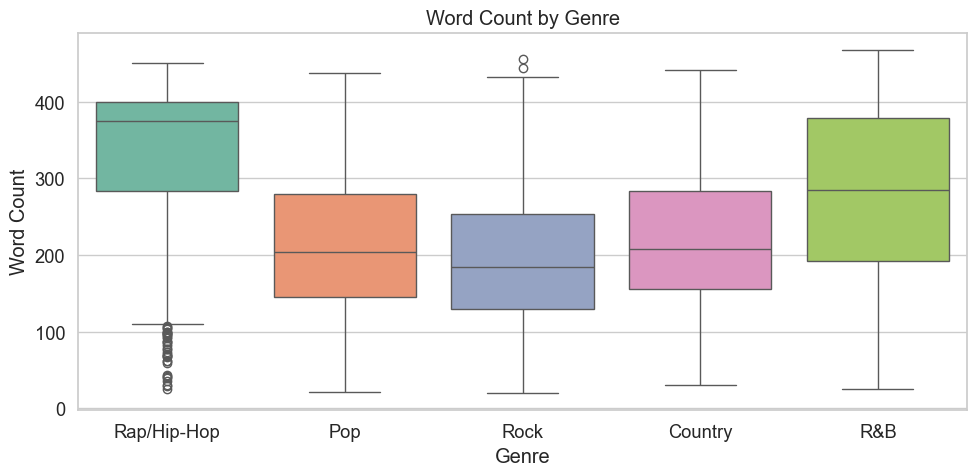

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_data = df[['genre', 'word_count']].copy()
plot_data['genre'] = plot_data['genre'].map(GENRE_LABELS)
sns.boxplot(data=plot_data, x='genre', y='word_count', palette=PALETTE,
            order=[GENRE_LABELS[g] for g in GENRE_ORDER], ax=ax)
ax.set_title('Word Count by Genre')
ax.set_xlabel('Genre')
ax.set_ylabel('Word Count')
plt.tight_layout()
plt.savefig('results/figures/word_count_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Word Clouds by Genre

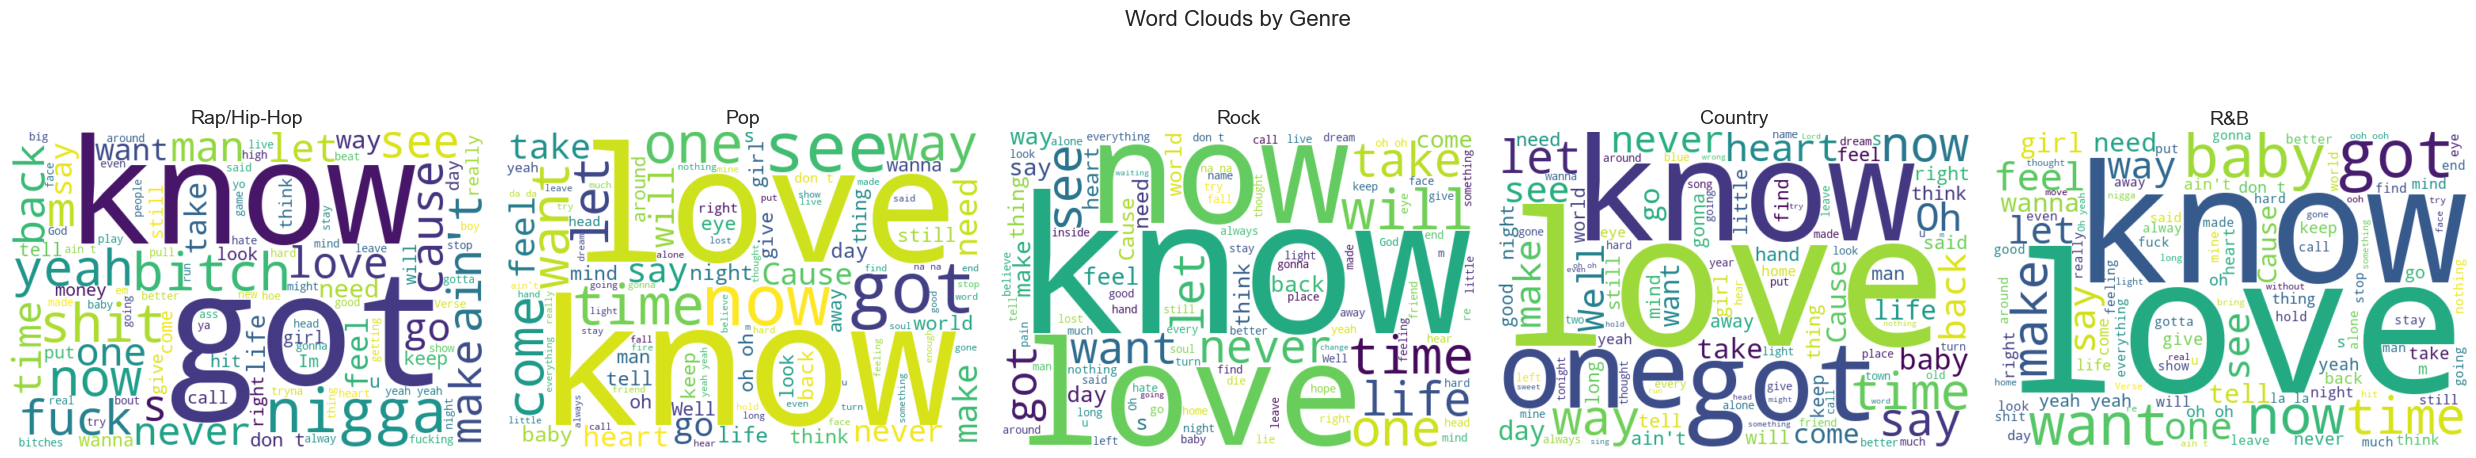

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for ax, genre in zip(axes, GENRE_ORDER):
    text = ' '.join(df[df['genre'] == genre]['lyrics'].values)
    wc = WordCloud(width=600, height=400, background_color='white',
                   max_words=100, colormap='viridis').generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(GENRE_LABELS[genre], fontsize=14)
    ax.axis('off')
plt.suptitle('Word Clouds by Genre', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('results/figures/word_clouds.png', dpi=150, bbox_inches='tight')
plt.show()

## 3b. TF-IDF Weighted Word Clouds

Replace raw-frequency word clouds with TF-IDF-weighted versions so genre-distinctive terms (not just common English words) stand out.

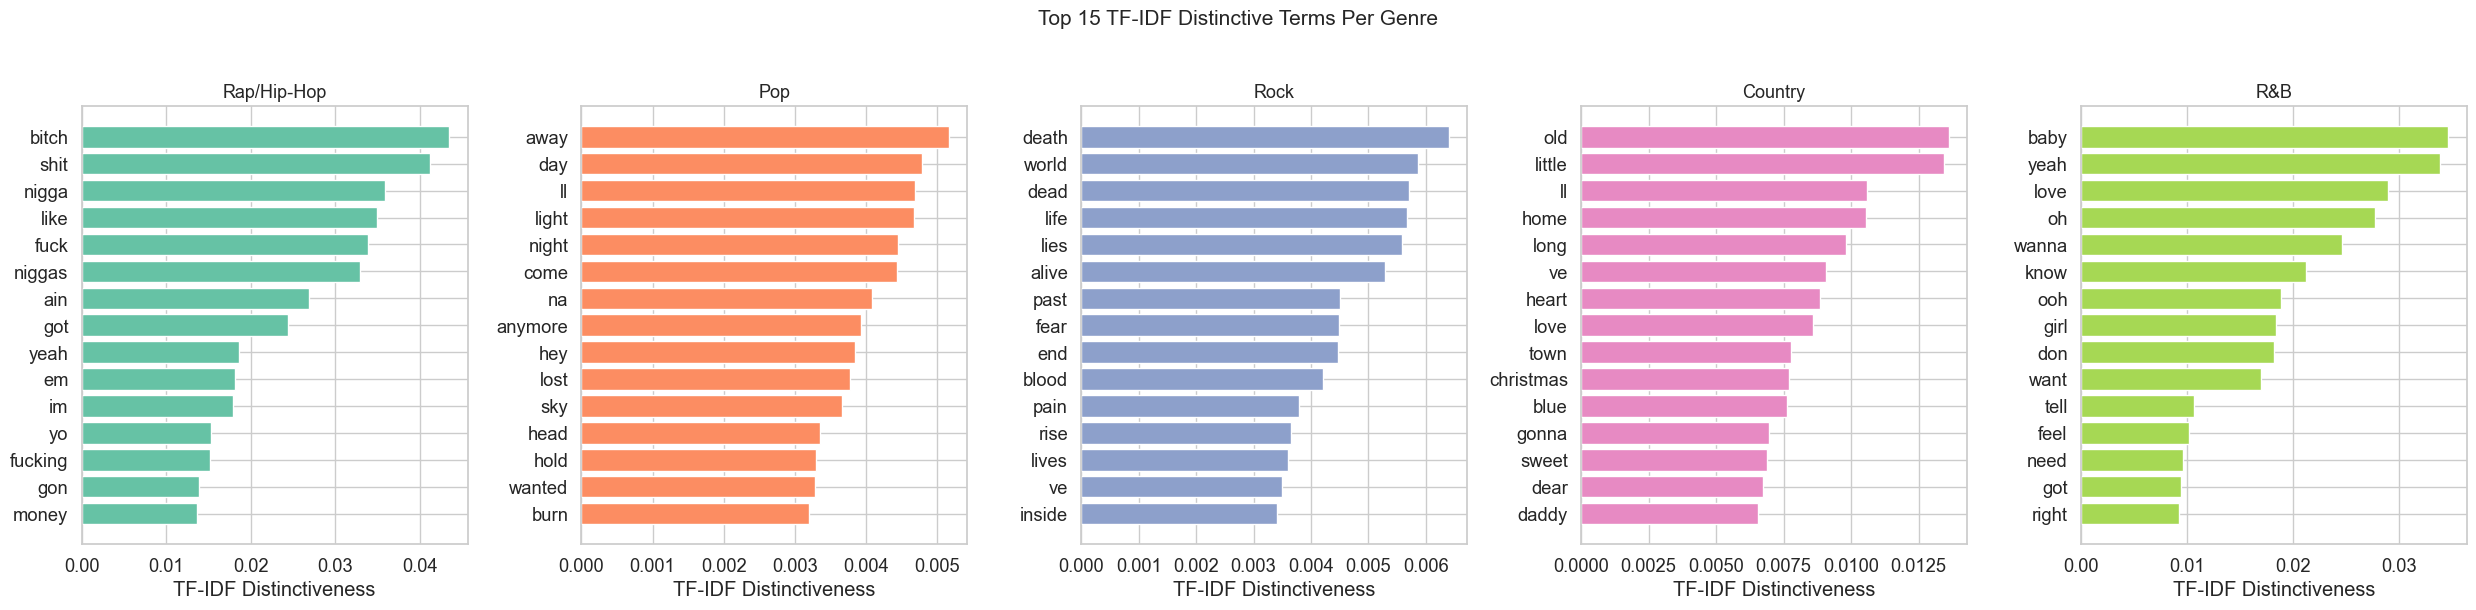

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Fit TF-IDF on the full corpus (training set only to avoid leakage in spirit, but EDA uses all)
tfidf = TfidfVectorizer(stop_words='english', max_features=10000, min_df=5)
tfidf_matrix = tfidf.fit_transform(df['lyrics'])
feature_names = np.array(tfidf.get_feature_names_out())

# For each genre, compute mean TF-IDF, then subtract mean of other genres → distinctive terms
fig, axes = plt.subplots(1, 5, figsize=(25, 6))
genre_tfidf_scores = {}
for ax, genre, color in zip(axes, GENRE_ORDER, PALETTE):
    mask = (df['genre'] == genre).values
    mean_this = np.asarray(tfidf_matrix[mask].mean(axis=0)).flatten()
    mean_others = np.asarray(tfidf_matrix[~mask].mean(axis=0)).flatten()
    diff = mean_this - mean_others
    genre_tfidf_scores[genre] = dict(zip(feature_names, diff))

    top_idx = diff.argsort()[-15:][::-1]
    ax.barh(feature_names[top_idx][::-1], diff[top_idx][::-1], color=color)
    ax.set_title(GENRE_LABELS[genre], fontsize=13)
    ax.set_xlabel('TF-IDF Distinctiveness')

plt.suptitle('Top 15 TF-IDF Distinctive Terms Per Genre', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('results/figures/tfidf_distinctive_terms.png', dpi=150, bbox_inches='tight')
plt.show()

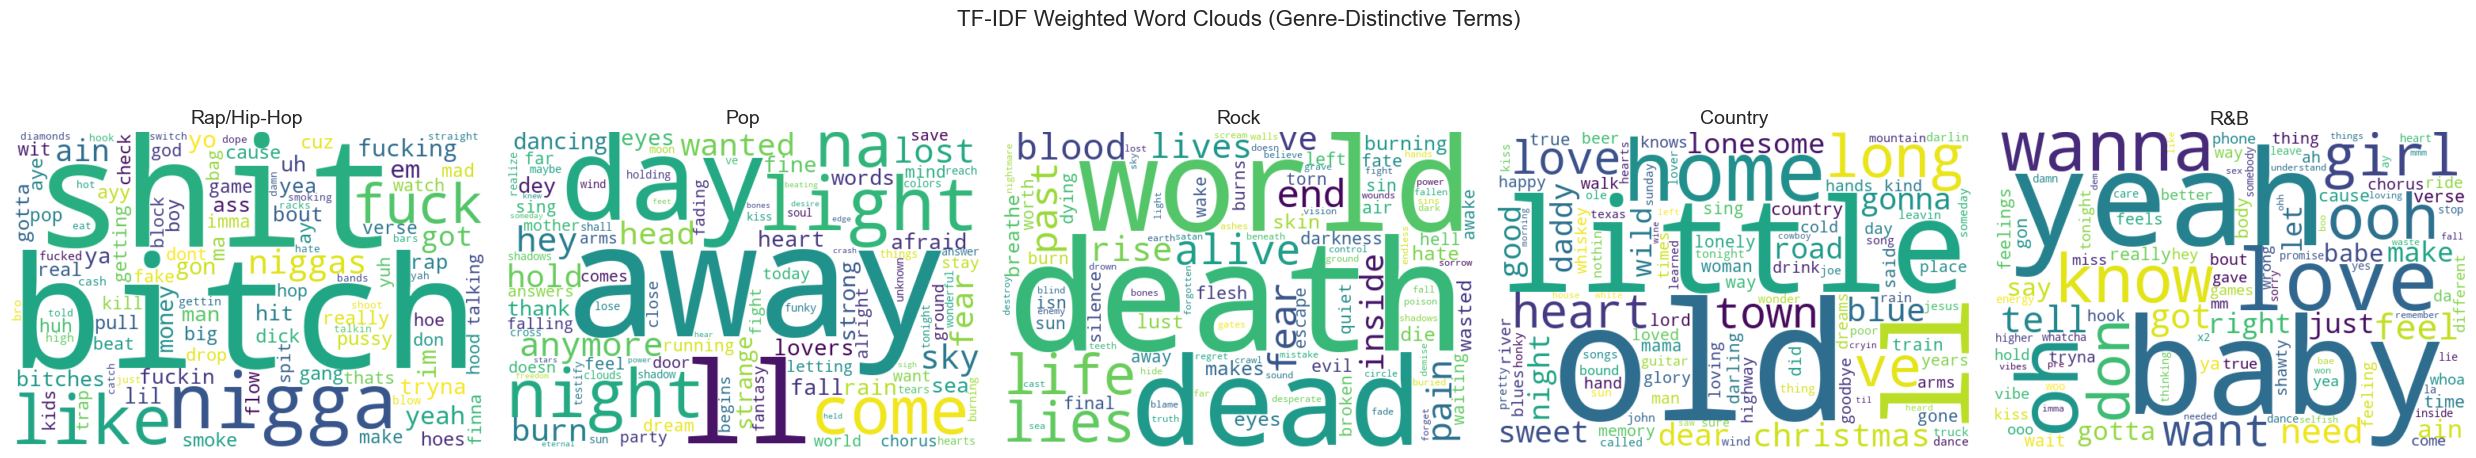

In [11]:
# TF-IDF weighted word clouds — genre-distinctive terms become prominent
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for ax, genre in zip(axes, GENRE_ORDER):
    # Keep only positive distinctiveness scores
    scores = {k: max(v, 0) for k, v in genre_tfidf_scores[genre].items() if v > 0}
    wc = WordCloud(width=600, height=400, background_color='white',
                   max_words=100, colormap='viridis').generate_from_frequencies(scores)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(GENRE_LABELS[genre], fontsize=14)
    ax.axis('off')
plt.suptitle('TF-IDF Weighted Word Clouds (Genre-Distinctive Terms)', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('results/figures/word_clouds_tfidf.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Bigram / Trigram Analysis

Top n-grams per genre reveal multi-word genre markers (e.g., country place names, rap slang phrases).

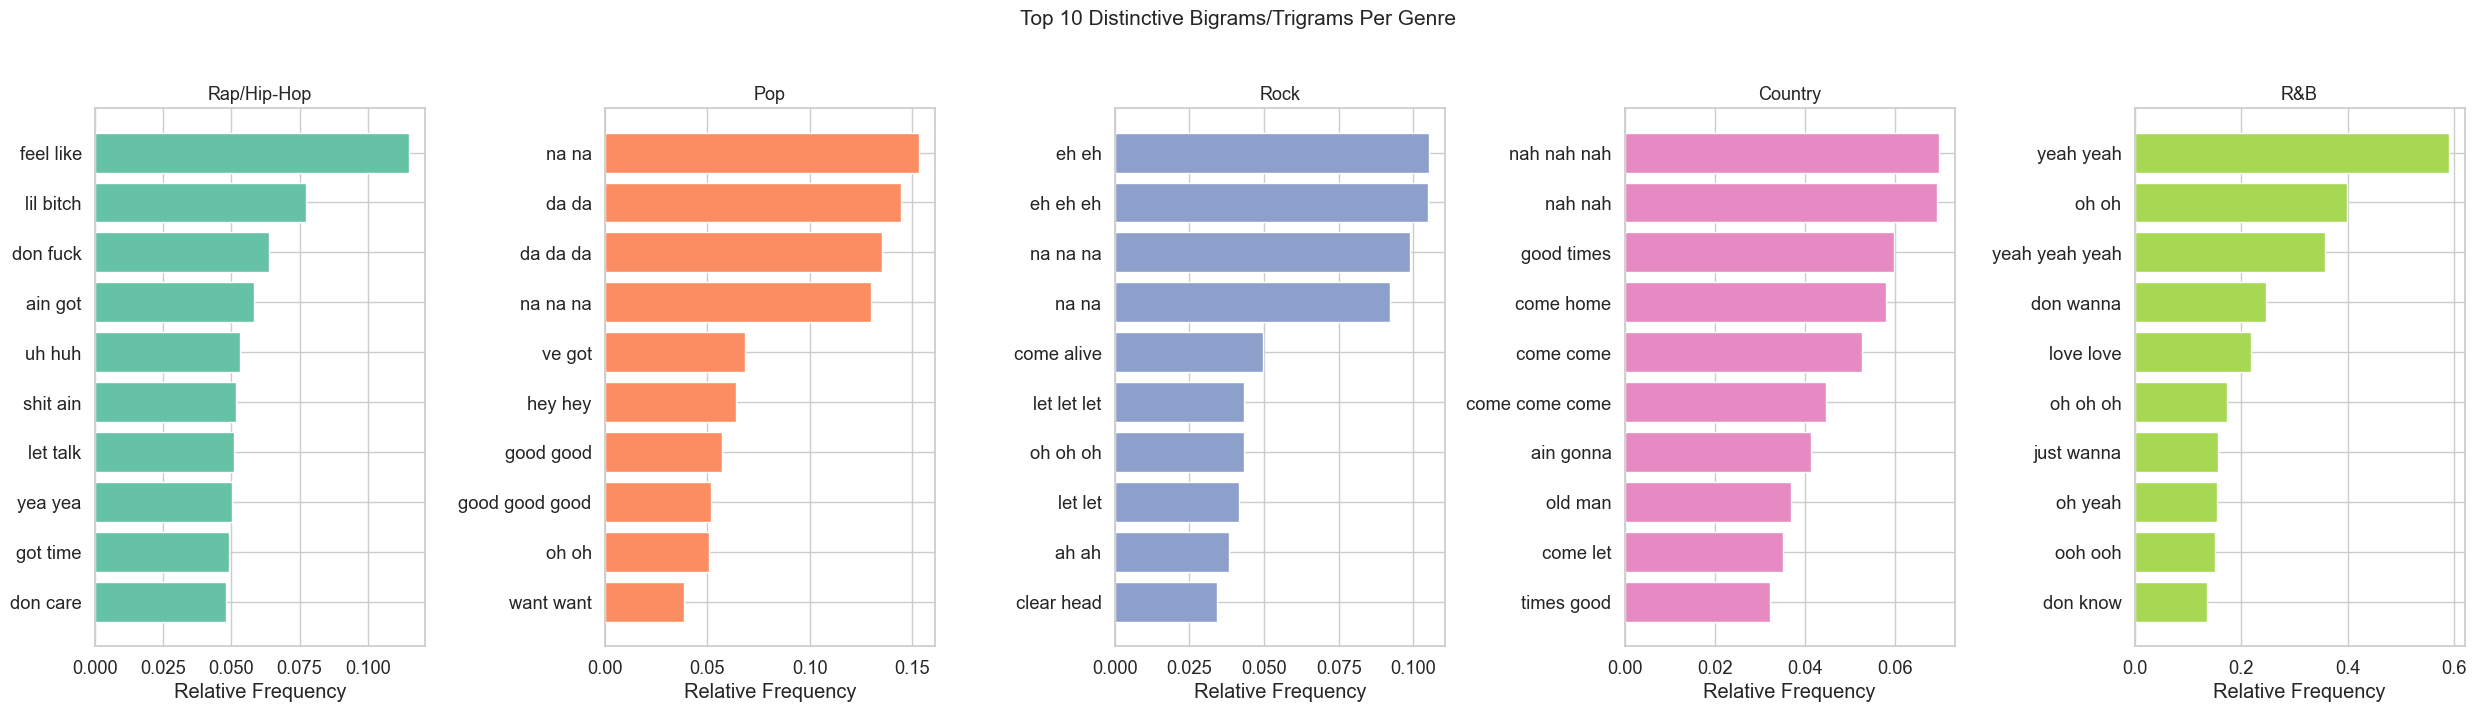

In [12]:
from sklearn.feature_extraction.text import CountVectorizer

ngram_vec = CountVectorizer(ngram_range=(2, 3), stop_words='english', max_features=20000, min_df=3)
ngram_matrix = ngram_vec.fit_transform(df['lyrics'])
ngram_names = np.array(ngram_vec.get_feature_names_out())

fig, axes = plt.subplots(1, 5, figsize=(25, 7))
for ax, genre, color in zip(axes, GENRE_ORDER, PALETTE):
    mask = (df['genre'] == genre).values
    counts_genre = np.asarray(ngram_matrix[mask].sum(axis=0)).flatten()
    counts_other = np.asarray(ngram_matrix[~mask].sum(axis=0)).flatten()
    # Normalize by number of documents
    freq_genre = counts_genre / mask.sum()
    freq_other = counts_other / (~mask).sum()
    diff = freq_genre - freq_other

    top_idx = diff.argsort()[-10:][::-1]
    ax.barh(ngram_names[top_idx][::-1], diff[top_idx][::-1], color=color)
    ax.set_title(GENRE_LABELS[genre], fontsize=13)
    ax.set_xlabel('Relative Frequency')

plt.suptitle('Top 10 Distinctive Bigrams/Trigrams Per Genre', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('results/figures/ngram_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Vocabulary Overlap Heatmap (Jaccard Similarity)

Pairwise lexical overlap between genres — the lexical counterpart to the semantic genre similarity analysis. Higher overlap means genres share more vocabulary, making classification harder.

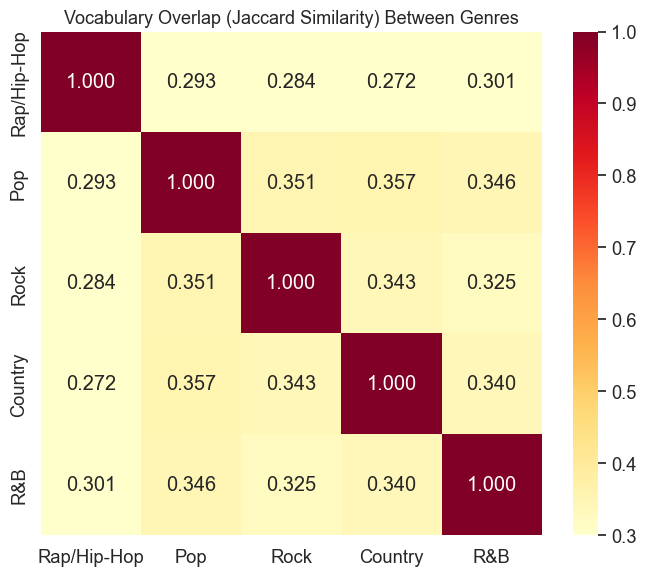

Rap/Hip-Hop    : 17,694 unique words
Pop            : 9,682 unique words
Rock           : 10,037 unique words
Country        : 8,373 unique words
R&B            : 8,959 unique words


In [13]:
import re
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

# Build unique word sets per genre (lowercased, alphabetic only, stopwords removed)
genre_vocabs = {}
for genre in GENRE_ORDER:
    texts = df[df['genre'] == genre]['lyrics'].values
    words = set()
    for text in texts:
        tokens = re.findall(r'[a-z]+', text.lower())
        words.update(t for t in tokens if t not in stop_words and len(t) > 2)
    genre_vocabs[genre] = words

# Pairwise Jaccard similarity
labels = [GENRE_LABELS[g] for g in GENRE_ORDER]
jaccard = np.zeros((5, 5))
for i, g1 in enumerate(GENRE_ORDER):
    for j, g2 in enumerate(GENRE_ORDER):
        intersection = len(genre_vocabs[g1] & genre_vocabs[g2])
        union = len(genre_vocabs[g1] | genre_vocabs[g2])
        jaccard[i, j] = intersection / union if union > 0 else 0

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(jaccard, annot=True, fmt='.3f', xticklabels=labels, yticklabels=labels,
            cmap='YlOrRd', vmin=0.3, vmax=1.0, ax=ax)
ax.set_title('Vocabulary Overlap (Jaccard Similarity) Between Genres', fontsize=13)
plt.tight_layout()
plt.savefig('results/figures/vocab_overlap_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print vocab sizes
for genre in GENRE_ORDER:
    print(f'{GENRE_LABELS[genre]:15s}: {len(genre_vocabs[genre]):,} unique words')

## 6. Type-Token Ratio (Vocabulary Richness)

TTR = unique words / total words per song. Higher TTR indicates more diverse vocabulary. Rap is expected to have the highest TTR (diverse vocab), while Pop/Country may show lower TTR (more repetitive choruses).

/var/folders/1t/64tr2w5177bdzft8dqnkzzwr0000gn/T/ipykernel_24900/48643620.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='genre', y='ttr', palette=PALETTE,


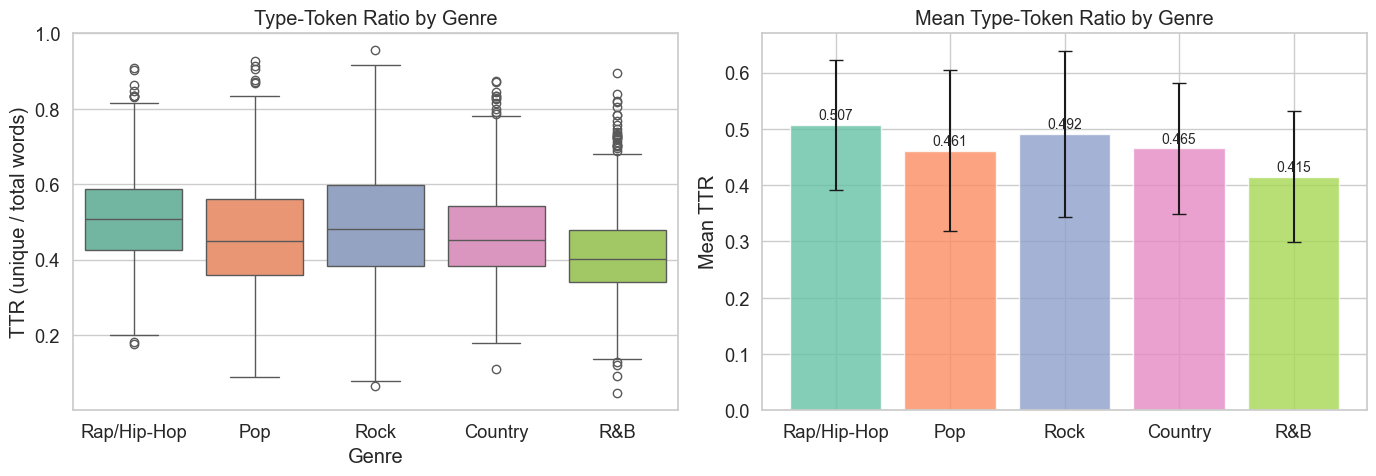

              mean  median    std
Rap/Hip-Hop  0.507   0.509  0.115
Pop          0.461   0.449  0.143
Rock         0.492   0.482  0.148
Country      0.465   0.452  0.116
R&B          0.415   0.402  0.116


In [14]:
def type_token_ratio(text):
    words = text.lower().split()
    if len(words) == 0:
        return 0
    return len(set(words)) / len(words)

df['ttr'] = df['lyrics'].apply(type_token_ratio)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
plot_data = df[['genre', 'ttr']].copy()
plot_data['genre'] = plot_data['genre'].map(GENRE_LABELS)
sns.boxplot(data=plot_data, x='genre', y='ttr', palette=PALETTE,
            order=[GENRE_LABELS[g] for g in GENRE_ORDER], ax=axes[0])
axes[0].set_title('Type-Token Ratio by Genre')
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('TTR (unique / total words)')

# Summary statistics
ttr_stats = df.groupby('genre')['ttr'].agg(['mean', 'median', 'std']).reindex(GENRE_ORDER)
ttr_stats.index = [GENRE_LABELS[g] for g in GENRE_ORDER]
bars = axes[1].bar(ttr_stats.index, ttr_stats['mean'], yerr=ttr_stats['std'],
                   color=PALETTE, capsize=5, alpha=0.8)
axes[1].set_title('Mean Type-Token Ratio by Genre')
axes[1].set_ylabel('Mean TTR')
for bar, val in zip(bars, ttr_stats['mean']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('results/figures/type_token_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

print(ttr_stats.round(3).to_string())

## 4. Sample Lyrics

In [15]:
for genre in GENRE_ORDER:
    sample = df[df['genre'] == genre].sample(1, random_state=42).iloc[0]
    print(f"=== {GENRE_LABELS[genre]} — {sample.get('title', 'N/A')} by {sample.get('artist', 'N/A')} ===")
    print(sample['lyrics'][:500])
    print('...\n')

=== Rap/Hip-Hop — Pollution by Digital Faceless ===
Drowning in the trash that lays on the ground
Brain fulfilled with thoughts polluting my mind
Watching the world rot as we are alive
Eating shitting killing polluting, that's what we are good at
We are braindead, fucking decerebrates
Never learning from our mistakes, we’re hopeless
Why the fuck you keep on listening and you're not changing
I despise all those parasites that try to get me

So much lack of physical activity
Theo's asking me if I'm okay, I respond to him with ''c'est la vie''
Feeli
...

=== Pop — Frayed Nerves by X-Trunk ===
Another blood injected
To join a line infected
Burying euphoria with one blink
And changing the color of our ink
I will not be the sheep in your flock
You've put your entirety on the block
Such a river against the grain
Crushing any movement
You want to crave the pain
You have rewrote the shame
Greeting avidity, greeting stupidity
A rust blade running on my tong
You want to crave the pain
You have re